# Basics of Regression and Classification Models Using the Housing Price Dataset

### 1. Introduction

Imagine you’re trying to buy a house, and you want to estimate its price based on factors like location, number of bedrooms, square footage, and so on. Or, imagine a realtor categorizing houses into price ranges for easy reference. These scenarios reflect two fundamental problems in machine learning: regression (predicting a continuous value) and classification (predicting a category).

In this session, we’ll explore how to use machine learning models to tackle these problems. We will:

 - Introduce a real-world dataset on housing prices.

 - Learn how to preprocess the data.

 - Perform exploratory data analysis (EDA).

 - Train and evaluate regression and classification models.

 - Deploy a trained model for real-world usage.



### 2. Introduction to the Dataset

Describing the dataset:

Context: This dataset contains information about housing prices in a specific county or city in the US. Each row corresponds to a house, and columns provide features like the number of bedrooms, bathrooms, square footage, location, etc.

Goal: Predict house prices (a regression problem) or classify houses into price ranges (a classification problem).

#### First load the libraries

In [120]:
import pandas as pd
import numpy as np   #these are standard aliases, do not change 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### Then load the dataset

In [121]:
df = pd.read_csv("kc_house_data.csv")

In [122]:
df.shape

(21613, 21)

In [123]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [124]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [125]:
len(df.columns)

21

In [126]:
#target column = price

In [127]:
#columns, dtypes and non-null count
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

#### Treatment of null values

In [128]:
# Getting number of nulls
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

This dataset doesn't have any nulls. But if there were some nulls, we would have to take care of them. Nulls are typically handled either by eliminating the entry (using drop) or by filling them in. 

Rows with na can be dropped as follows: 

```python
df = df.dropna()
```
Note that drop is a more general function 
```python
df = df.drop(column_names, axis=1) # drops columns
df = df.drop(row_names, axis=0) # drops rows
```

Alternatively, you can fill the na values with median values of the column. This, for obvious reasons, works only for numerical columns. 
```python 
df = df.fillna(df.median()) #replace with df.mean() to fill with mean and not median
```
There are other options as well, like forward fill
```python
df.fillna(method = 'ffill', inplace=True) #note the use of inplace
```
if you do not use inplace = True, the result is lost. Alternatively, you can easily do
```python
df = df.fillna(method='ffill')
```

#### Select needed columns
Not all columns are necessary. Just select the columns which can be used later. 

In [129]:
cols_to_drop = ['id', 'date', 'lat', 'long'] 
df = df.drop(cols_to_drop, axis=1) 

In [130]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,1800,7503


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  sqft_living15  21613 non-null  int64  
 16  sqft_lot15     21613 non-null  int64  
dtypes: float64(3), int64(14)
memory usage: 2.8 MB


In [132]:
df.nunique()

price            4028
bedrooms           13
bathrooms          30
sqft_living      1038
sqft_lot         9782
floors              6
waterfront          2
view                5
condition           5
grade              12
sqft_above        946
sqft_basement     306
yr_built          116
yr_renovated       70
zipcode            70
sqft_living15     777
sqft_lot15       8689
dtype: int64

In [133]:
df.grade.unique()

array([ 7,  6,  8, 11,  9,  5, 10, 12,  4,  3, 13,  1])

## 3. Exploratory Data Analysis

### Best is to plot
The best way to do exploratory data analysis is to plot variables. 

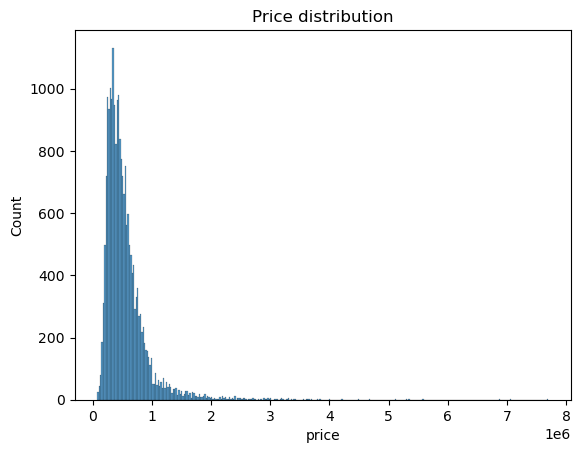

In [134]:
# First plot prices - for inspection 
sns.histplot(df['price'])
plt.title('Price distribution')
plt.show()

Notice the very long tail! This tail contains very high prices, but they are very few in number. 
we will eliminate the tail by keeping only those rows whose prices are in the first 95-percentile. 

In [135]:
df = df[df['price'] <= df.price.quantile(0.95)]

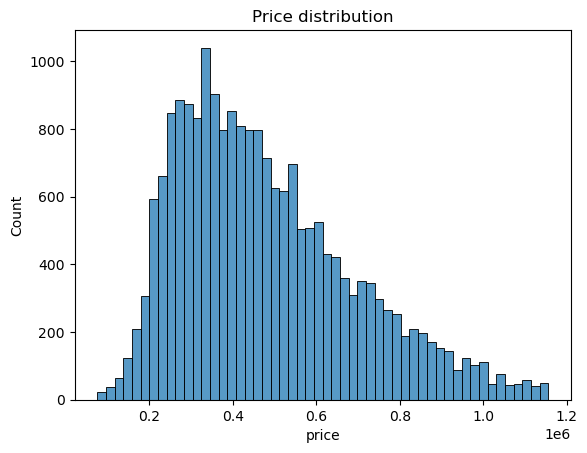

In [136]:
sns.histplot(df['price'])
plt.title('Price distribution')
plt.show()

### Get the correlation between the different variables
This is a crucial bit of information as whether the features will be kept for the final analysis. 

In [137]:
corr = df.corr()

In [138]:
corr

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
price,1.000000,0.299076,0.459821,0.627526,0.096770,0.273289,0.059553,0.243615,0.036566,0.635616,0.535522,0.239368,0.063737,0.083304,-0.021262,0.568382,0.083926
bedrooms,0.299076,1.000000,0.495219,0.584744,0.026231,0.154337,-0.030892,0.039907,0.025458,0.324452,0.464020,0.285545,0.160744,0.003741,-0.147784,0.371940,0.022299
bathrooms,0.459821,0.495219,1.000000,0.718252,0.067795,0.500811,-0.003400,0.099191,-0.136581,0.616788,0.640090,0.225500,0.543223,0.025155,-0.206918,0.531699,0.066541
sqft_living,0.627526,0.584744,0.718252,1.000000,0.163253,0.340947,0.003311,0.171929,-0.073741,0.709020,0.855185,0.378238,0.354217,0.020448,-0.204828,0.740339,0.174532
sqft_lot,0.096770,0.026231,0.067795,0.163253,1.000000,-0.015991,0.025241,0.077353,-0.003491,0.096024,0.166629,0.013497,0.043618,0.011347,-0.130003,0.144552,0.710190
floors,0.273289,0.154337,0.500811,0.340947,-0.015991,1.000000,-0.001593,-0.012265,-0.277684,0.456277,0.528023,-0.293333,0.511115,-0.002375,-0.064750,0.269113,-0.020860
waterfront,0.059553,-0.030892,-0.003400,0.003311,0.025241,-0.001593,1.000000,0.300093,0.012862,-0.010698,-0.004574,0.014478,-0.040075,0.066060,0.043292,0.007351,0.032205
view,0.243615,0.039907,0.099191,0.171929,0.077353,-0.012265,0.300093,1.000000,0.034099,0.135467,0.070332,0.202012,-0.064605,0.065440,0.099448,0.190355,0.074974
condition,0.036566,0.025458,-0.136581,-0.073741,-0.003491,-0.277684,0.012862,0.034099,1.000000,-0.168180,-0.178666,0.178572,-0.354371,-0.059773,-0.004739,-0.118031,0.001326
grade,0.635616,0.324452,0.616788,0.709020,0.096024,0.456277,-0.010698,0.135467,-0.168180,1.000000,0.712715,0.078202,0.490923,-0.020329,-0.185437,0.674639,0.102914


<Axes: >

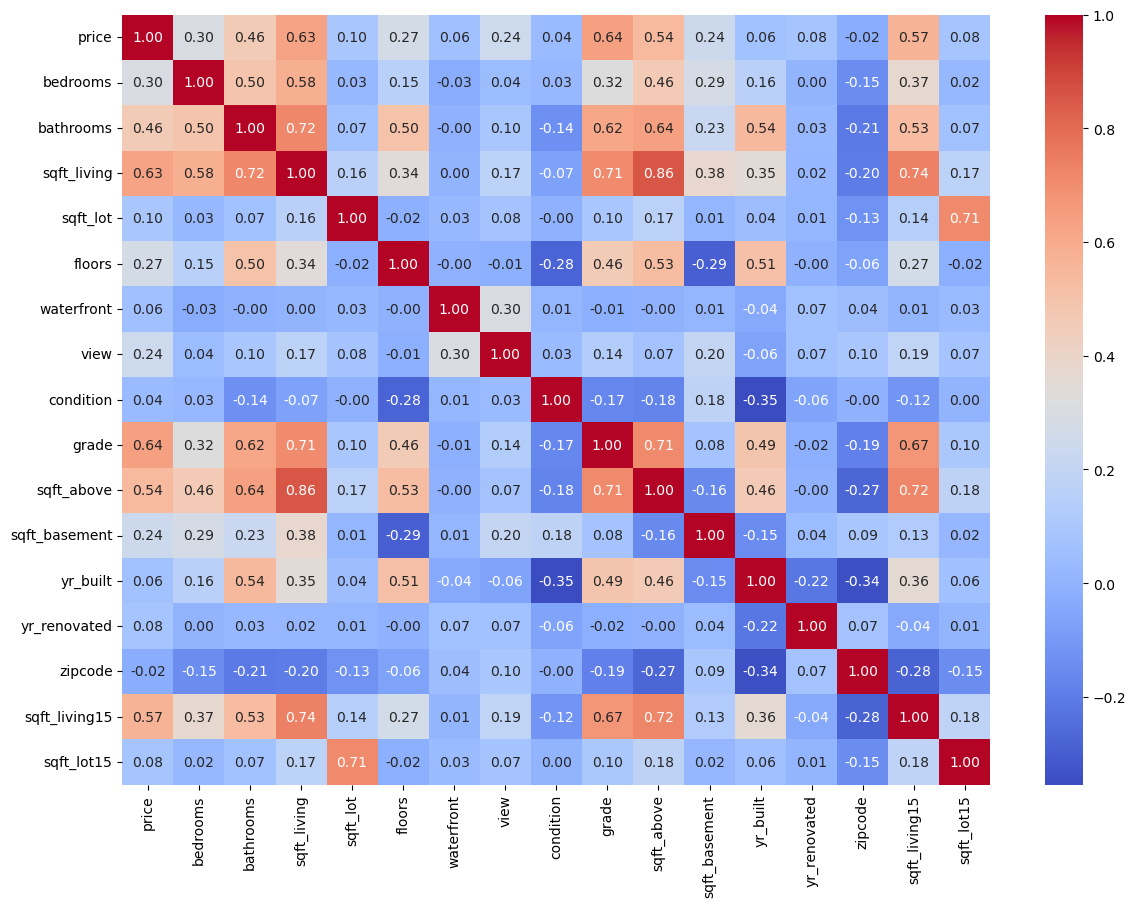

In [139]:
# But plot it as a heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr, 
    annot=True,          # Show correlation values
    fmt=".2f",           # Format the numbers to 2 decimal places
    cbar=True,           # Show color bar   
    cmap='coolwarm',     # Color map
)

#### Area 
This might be the most important numerical variable to determine price

In [140]:
area_features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']

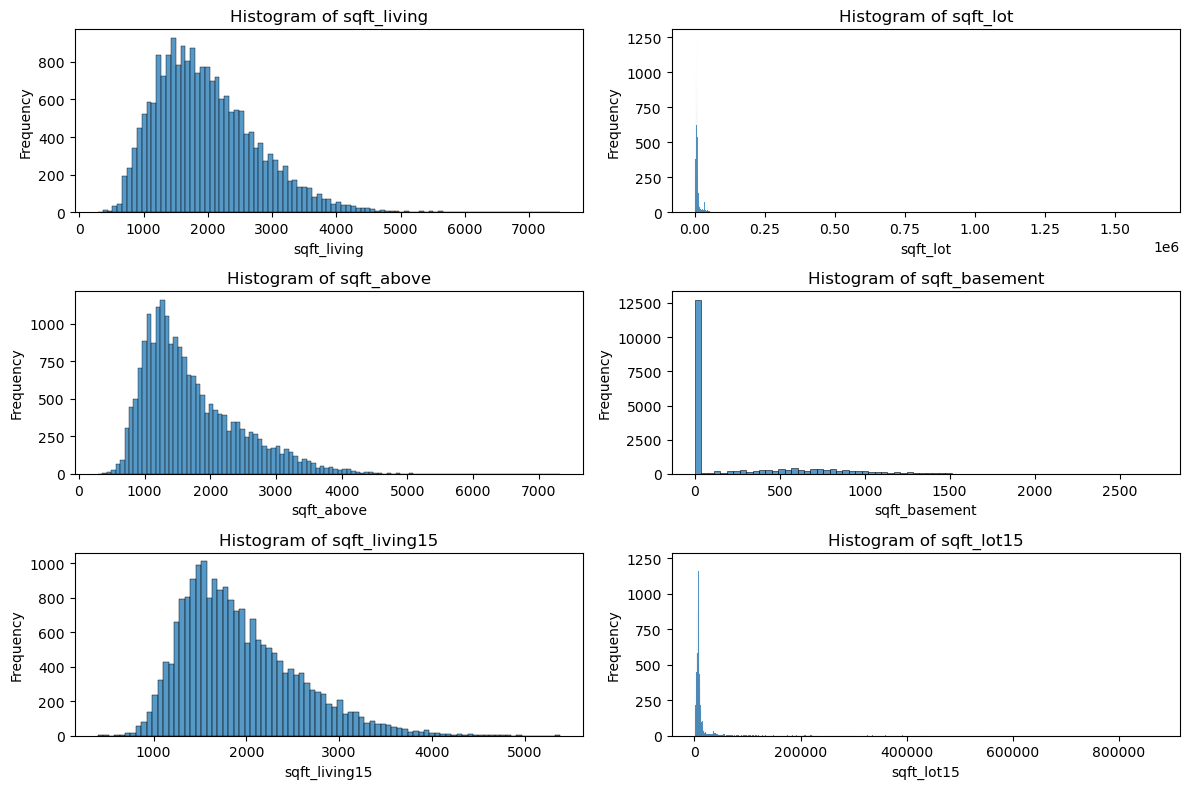

In [141]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(area_features,1):
    plt.subplot(3, 2, i)  # Adjust the grid (e.g., 2x2) based on the number of features
    sns.histplot(df[feature])
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [142]:
for feature in area_features:
    df = df[df[feature] <= df[feature].quantile(0.95)]

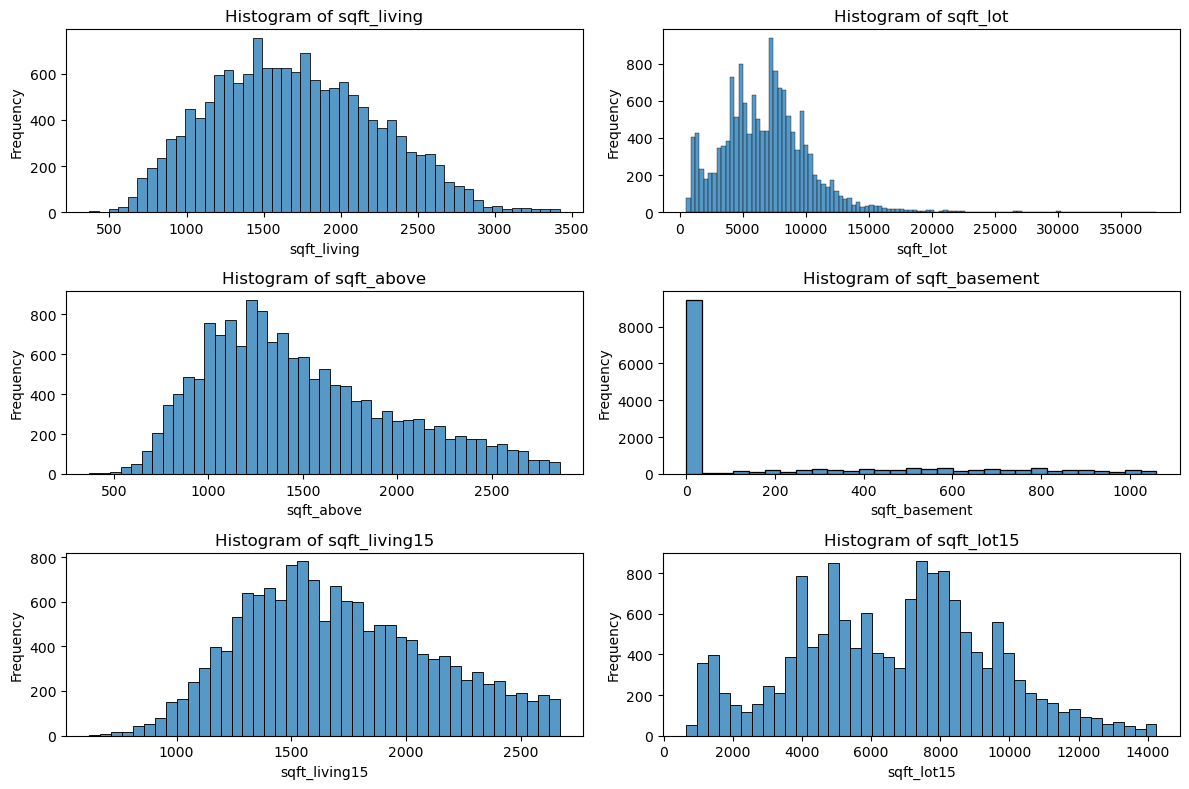

In [143]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(area_features,1):
    plt.subplot(3, 2, i)  
    sns.histplot(df[feature])
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [144]:
df.shape

(15146, 17)

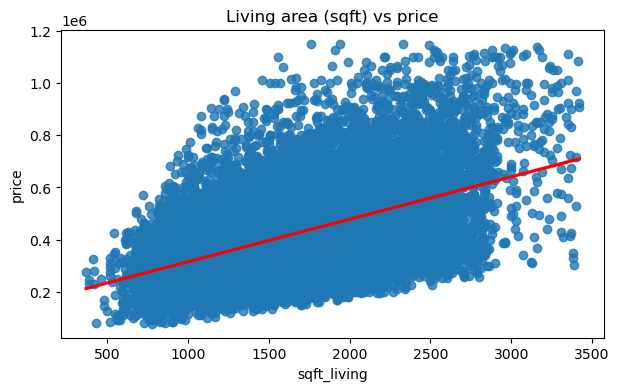

In [145]:
fig = plt.figure(figsize = (7, 4))

plt.title('Living area (sqft) vs price')
sns.regplot(x='sqft_living', y='price', data=df, line_kws={'color': 'red'})
plt.show()

### Year columns
Let's inspect the year columns. 
Built year: We will use it as a decade. 
Renovation year: We will use partial information - just whether it has been renovated or not. 

In [146]:
df['decade_built'] = df['yr_built'].astype(int) //10 * 10

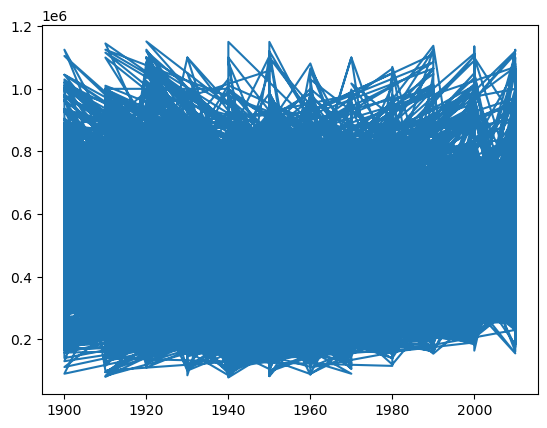

In [147]:
plt.plot(df['decade_built'], df['price'])

This is not informative. Better to plot the median price given decade. 

In [148]:
df[['decade_built','price','sqft_living']].groupby('decade_built').median()

,price,sqft_living
decade_built,,
1900,521000.0,1510.0
1910,485000.0,1480.0
1920,519000.0,1560.0
1930,425000.0,1450.0
1940,370000.0,1290.0
1950,365000.0,1480.0
1960,341500.0,1670.0
1970,375000.0,1810.0
1980,369000.0,1770.0


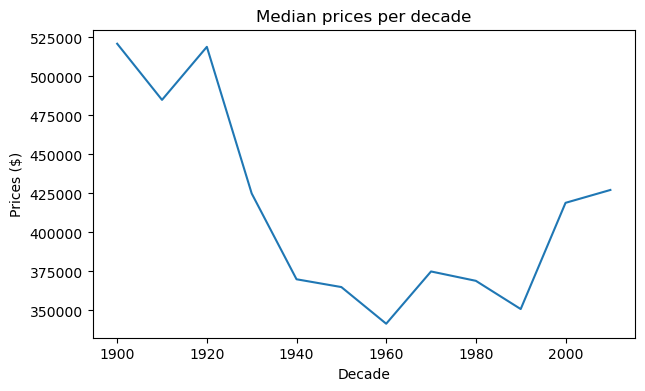

In [149]:
fig = plt.figure(figsize = (7,4))
plt.plot(df[['decade_built', 'price']].groupby('decade_built').median())
plt.title('Median prices per decade')
plt.xlabel('Decade')
plt.ylabel('Prices ($)')
plt.show()

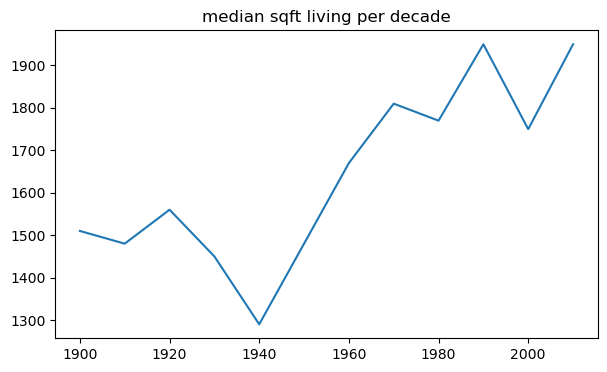

In [150]:
fig = plt.figure(figsize = (7,4))
plt.plot(df[['decade_built','sqft_living']].groupby('decade_built').median())
plt.title('median sqft living per decade')
plt.show()   

In [151]:
## This is how you count the number of times a value occurs
df['yr_renovated'].value_counts()

yr_renovated
0       14604
2014       67
2013       24
2005       21
2000       19
        ...  
1934        1
1962        1
1944        1
1948        1
1957        1
Name: count, Length: 69, dtype: int64

In [152]:
#Condense this information into a single binary category column
df['renovated'] = df['yr_renovated'] != 0

In [153]:
df.renovated.nunique()

2

In [154]:
df.renovated.value_counts()

renovated
False    14604
True       542
Name: count, dtype: int64

<Axes: xlabel='renovated', ylabel='price'>

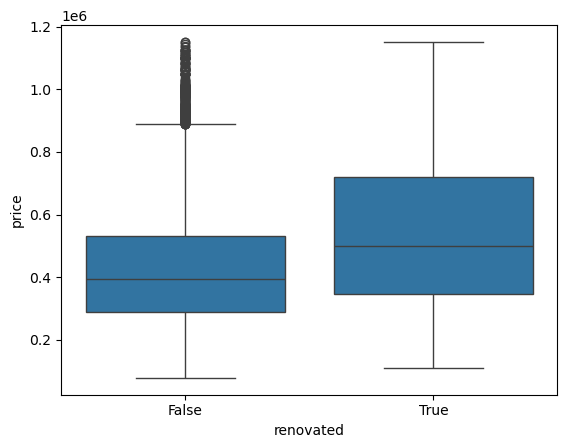

In [155]:
sns.boxplot(x='renovated', y='price', data=df)

### Condition - there are only a few categories

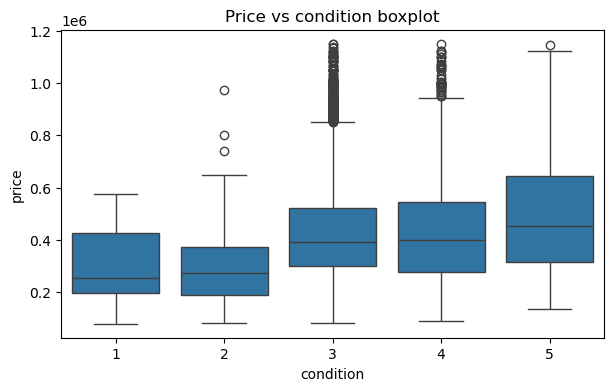

In [156]:
plt.figure(figsize = (7,4))
sns.boxplot(x='condition', y='price', data=df)
plt.title('Price vs condition boxplot')
plt.show()

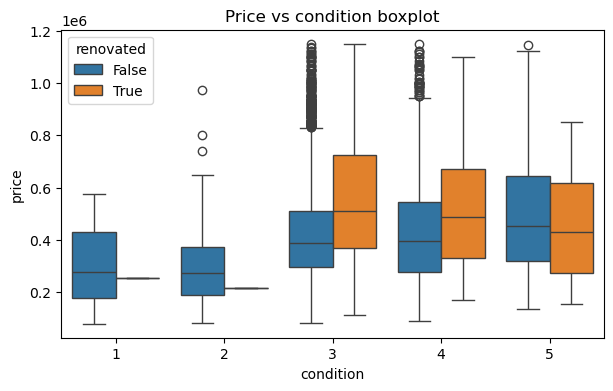

In [157]:
plt.figure(figsize = (7,4))
sns.boxplot(x='condition', y='price', data=df, hue = 'renovated')
plt.title('Price vs condition boxplot')
plt.show()

### Now onto grade

In [158]:
df.grade.value_counts()

grade
7     7791
8     4370
6     1841
9      851
5      194
10      78
4       18
11       2
3        1
Name: count, dtype: int64

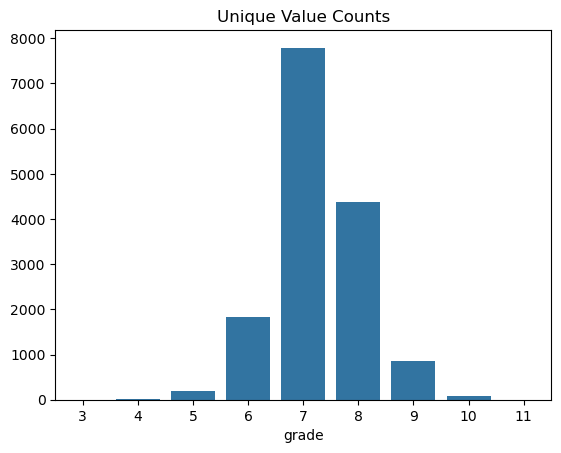

In [159]:
sns.barplot(x=df.grade.value_counts().index, y=df.grade.value_counts().values)
plt.title("Unique Value Counts")
plt.show()

We can transform this entire thing to a 1-5 grade scale. Anything in the original scale below 6 will be given grade 1, anything above 9 will be 5. Anything in between will be scaled properly. 

Use pd.cut to make bins

In [160]:
bins = [0, 6, 7,8, 9, 12]  # Define cut-off points
labels = [1, 2, 3, 4, 5]  # Corresponding labels for bins

# Create binned column
df['binned_grade'] = pd.cut(df['grade'], bins=bins, labels=labels, include_lowest=True)

In [161]:
df[['grade', 'binned_grade']].drop_duplicates()

,grade,binned_grade
0,7,2
4,8,3
15,9,4
25,6,1
36,5,1
465,4,1
546,10,5
3223,3,1
15230,11,5


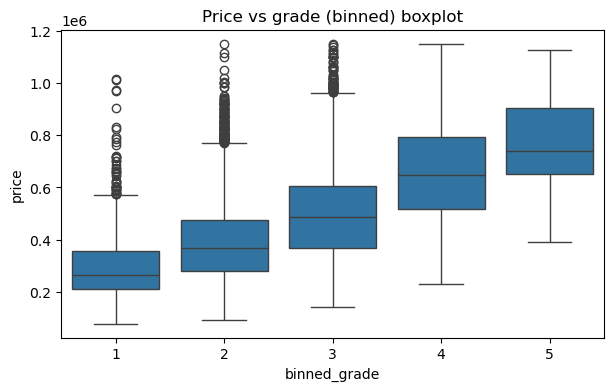

In [162]:
plt.figure(figsize = (7,4))
sns.boxplot(x='binned_grade', y='price', data=df)
plt.title('Price vs grade (binned) boxplot')
plt.show()

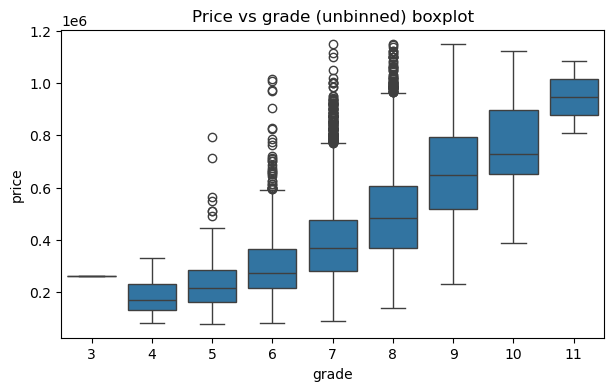

In [163]:
plt.figure(figsize = (7,4))
sns.boxplot(x='grade', y='price', data=df)
plt.title('Price vs grade (unbinned) boxplot')
plt.show()

### Now inspect the number of bedrooms and bathrooms

In [164]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'sqft_living15',
       'sqft_lot15', 'decade_built', 'renovated', 'binned_grade'],
      dtype='object')

In [165]:
df.bedrooms.value_counts()

bedrooms
3     7851
4     3923
2     2491
5      595
1      164
6       97
7       10
0        9
8        2
11       1
33       1
9        1
10       1
Name: count, dtype: int64

In [166]:
df = df[df['bedrooms']<=6]

In [167]:
df.bedrooms.value_counts()

bedrooms
3    7851
4    3923
2    2491
5     595
1     164
6      97
0       9
Name: count, dtype: int64

In [168]:
df.bathrooms.value_counts()

bathrooms
1.00    3541
2.50    3409
1.75    2433
2.00    1581
2.25    1494
1.50    1270
2.75     532
3.00     378
3.50     202
3.25     185
0.75      44
3.75      21
4.00      17
1.25       7
0.50       4
0.00       4
4.50       4
4.25       2
5.00       1
5.25       1
Name: count, dtype: int64

This is very weird! 
There are fractional bathrooms. 

In the American standard, a full bathroom contains a bathtub, shower, sink and toilet, while in a fractional bathroom, one of them is missing, typically the bathtub. Let's call these half-bath. 

https://www.homelight.com/blog/buyer-what-is-a-half-bath/


In [169]:
df['full_baths'] = df['bathrooms'].astype(int)
df['half_baths'] = df['bathrooms']%1  > 0 

In [170]:
df.half_baths

0        False
1         True
3        False
4        False
6         True
         ...  
21608     True
21609     True
21610     True
21611     True
21612     True
Name: half_baths, Length: 15130, dtype: bool

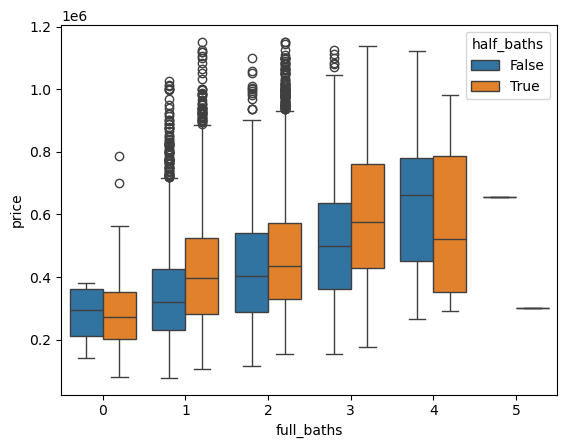

In [171]:
sns.boxplot(x='full_baths',y='price', data=df, hue = 'half_baths')
plt.show()

In [172]:
df.zipcode

0        98178
1        98125
3        98136
4        98074
6        98003
         ...  
21608    98103
21609    98146
21610    98144
21611    98027
21612    98144
Name: zipcode, Length: 15130, dtype: int64

<Axes: xlabel='zipcode', ylabel='price'>

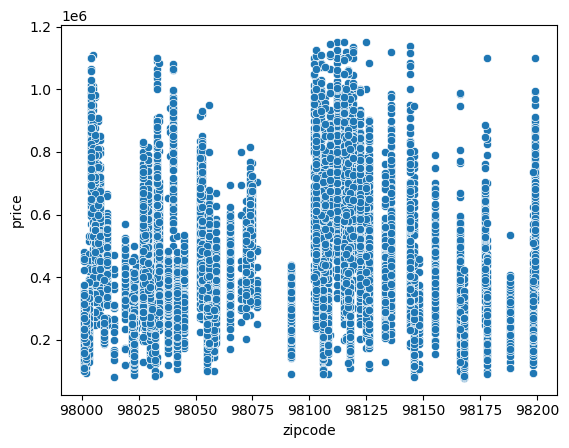

In [173]:
sns.scatterplot(x='zipcode', y='price', data=df)

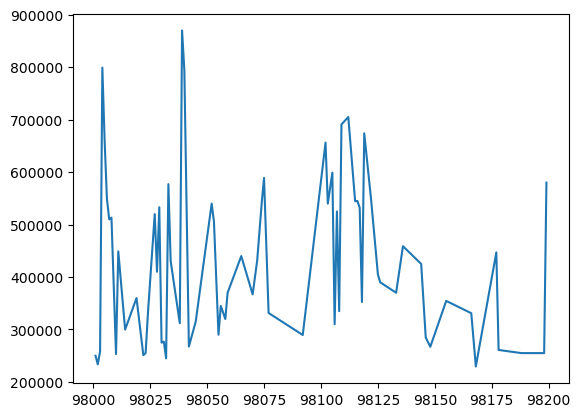

In [174]:
plt.plot(df.groupby('zipcode')['price'].median())

In [175]:
# Add a column for the price category 
df['price_category'] = pd.qcut(df['price'], q=5, labels=[1, 2, 3, 4, 5])

In [176]:
df.price_category

0        1
1        4
3        5
4        4
6        1
        ..
21608    3
21609    3
21610    3
21611    3
21612    2
Name: price_category, Length: 15130, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

In [192]:
df['has_basement'] = df['sqft_basement']>0

### Review and select_features

In [177]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'sqft_living15',
       'sqft_lot15', 'decade_built', 'renovated', 'binned_grade', 'full_baths',
       'half_baths', 'price_category'],
      dtype='object')

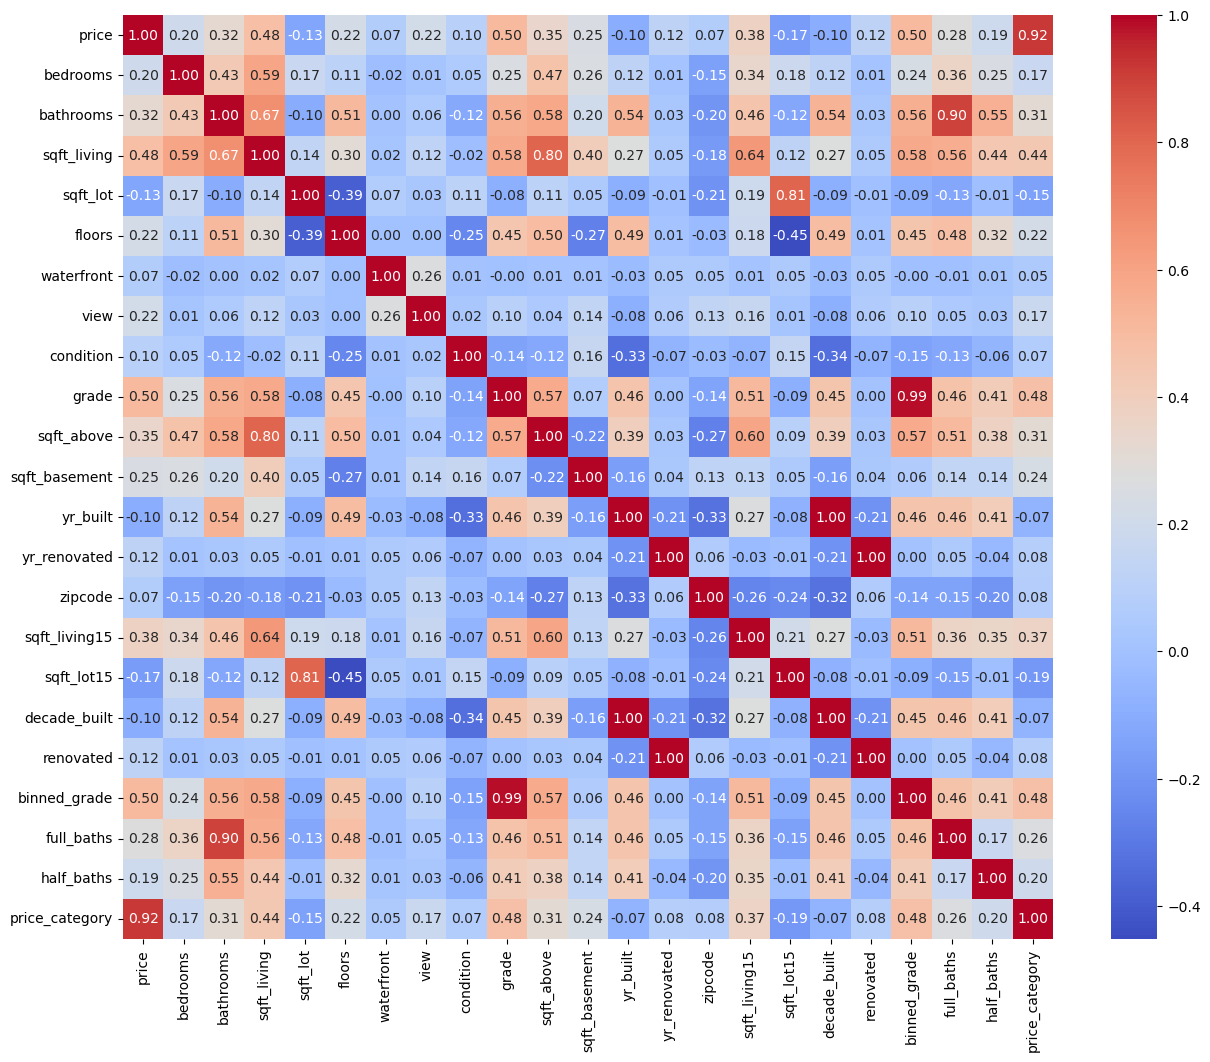

In [178]:
plt.figure(figsize=(15,12))
sns.heatmap(
    df.corr(),
    annot=True,          # Show correlation values
    fmt=".2f",           # Format the numbers to 2 decimal places
    cbar=True,           # Show color bar   
    cmap='coolwarm',     # Color map
)
plt.show()

In [179]:
df_grouped = df.groupby(by='zipcode').agg(region_price=('price', 'mean')).reset_index()
df_grouped['quartile_zone'] = pd.qcut(df_grouped['region_price'], q=4, labels=[1, 2, 3, 4])
df = df.merge(df_grouped[['zipcode', 'quartile_zone']], how='left', on='zipcode')

<Axes: xlabel='floors', ylabel='price'>

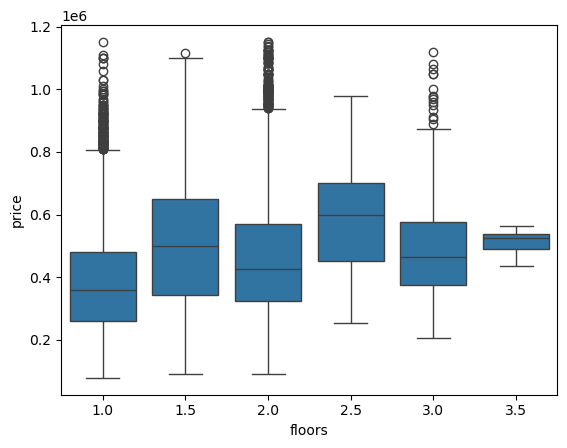

In [194]:
sns.boxplot(x='floors', y='price', data=df)

In [195]:
#Select columns with the highest correlation with prices
#awesome chain functionality!
feature_columns = df.corr()['price'].drop('price').sort_values(ascending=False)

In [196]:
feature_columns

price_category    0.918487
quartile_zone     0.698133
binned_grade      0.504990
grade             0.504133
sqft_living       0.478737
sqft_living15     0.378061
sqft_above        0.347264
bathrooms         0.324146
full_baths        0.275449
sqft_basement     0.250368
has_basement      0.231533
floors            0.219985
view              0.215731
bedrooms          0.197755
half_baths        0.192174
yr_renovated      0.118261
renovated         0.117782
condition         0.096438
zipcode           0.074055
waterfront        0.073333
decade_built     -0.096469
yr_built         -0.097606
sqft_lot         -0.133403
sqft_lot15       -0.172311
Name: price, dtype: float64

In [65]:
list(feature_columns.index)

['price_category',
 'binned_grade',
 'grade',
 'sqft_living',
 'sqft_living15',
 'sqft_above',
 'bathrooms',
 'full_baths',
 'sqft_basement',
 'floors',
 'view',
 'bedrooms',
 'half_baths',
 'sqft_lot15',
 'sqft_lot']

In [197]:
cols_to_select = ['quartile_zone', 'grade', 'sqft_living', 'full_baths', 'has_basement', 'floors', 'view','half_baths']

In [66]:
selected_columns = list(feature_columns[1:].index)
selected_columns

['binned_grade',
 'grade',
 'sqft_living',
 'sqft_living15',
 'sqft_above',
 'bathrooms',
 'full_baths',
 'sqft_basement',
 'floors',
 'view',
 'bedrooms',
 'half_baths',
 'sqft_lot15',
 'sqft_lot']

## 4. Linear Regression


First we carry out simple linear regression.
For this, we will use built-in functions from the scikit-learn package. 

Later we will use the price categories to do logistic regression. 

In [198]:
X = df[cols_to_select]  #if you want to include all column, except price, just use df.drop('price')
y = df['price']

In [199]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [200]:
print('Training shape:', X_train.shape,
y_train.shape)
print('Testing shape:', X_test.shape,
y_test.shape)

Training shape: (12104, 8) (12104,)
Testing shape: (3026, 8) (3026,)


In [201]:
X_test.shape

(3026, 8)

In [202]:
## First scale appropriately
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Note that these return numpy arrays

In [203]:
# Train a model using the scaled data
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred)

Predictions: [264052.90943347 443352.49804899 478220.79424938 ... 509104.43445011
 371297.76140728 330144.27346239]


We need to briefly evaluate the model, in case we want to compare with another model. 

In [204]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 69173.26892245981
Mean Squared Error (MSE): 8546517581.923799
Root Mean Squared Error (RMSE): 92447.37736639043
R-squared (R²): 0.7425605527994512


In [205]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

In [206]:
X.columns

Index(['quartile_zone', 'grade', 'sqft_living', 'full_baths', 'has_basement',
       'floors', 'view', 'half_baths'],
      dtype='object')

In [207]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15130 entries, 0 to 15129
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   quartile_zone  15130 non-null  category
 1   grade          15130 non-null  int64   
 2   sqft_living    15130 non-null  int64   
 3   full_baths     15130 non-null  int64   
 4   has_basement   15130 non-null  bool    
 5   floors         15130 non-null  float64 
 6   view           15130 non-null  int64   
 7   half_baths     15130 non-null  bool    
dtypes: bool(2), category(1), float64(1), int64(4)
memory usage: 635.7 KB


In [208]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [209]:
## First scale appropriately
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [210]:
model_ols = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     4095.
Date:                Tue, 14 Jan 2025   Prob (F-statistic):               0.00
Time:                        00:58:51   Log-Likelihood:            -1.5570e+05
No. Observations:               12104   AIC:                         3.114e+05
Df Residuals:                   12095   BIC:                         3.115e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.295e+05    849.554    505.583      0.0

### VIF

In [211]:
vif = pd.DataFrame({'feature':X_train.columns})
vif['VIF'] = [variance_inflation_factor((X_train * 1).values, i) for i in range(X_train.shape[1])]
vif.sort_values(by= 'VIF', ascending=False)

TypeError: unsupported operand type(s) for *: 'Categorical' and 'int'

In [213]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12104 entries, 14985 to 7270
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   quartile_zone  12104 non-null  category
 1   grade          12104 non-null  int64   
 2   sqft_living    12104 non-null  int64   
 3   full_baths     12104 non-null  int64   
 4   has_basement   12104 non-null  bool    
 5   floors         12104 non-null  float64 
 6   view           12104 non-null  int64   
 7   half_baths     12104 non-null  bool    
dtypes: bool(2), category(1), float64(1), int64(4)
memory usage: 603.0 KB


In [214]:
X_train['quartile_zone'] = pd.to_numeric(X_train['quartile_zone'])

In [215]:
vif = pd.DataFrame({'feature':X_train.columns})
vif['VIF'] = [variance_inflation_factor((X_train * 1).values, i) for i in range(X_train.shape[1])]
vif.sort_values(by= 'VIF', ascending=False)

,feature,VIF
1,grade,30.247263
2,sqft_living,23.982334
3,full_baths,14.381345
5,floors,14.217530
0,quartile_zone,7.085264
7,half_baths,3.807693
4,has_basement,2.139116
6,view,1.077903


### Homoscedasticity

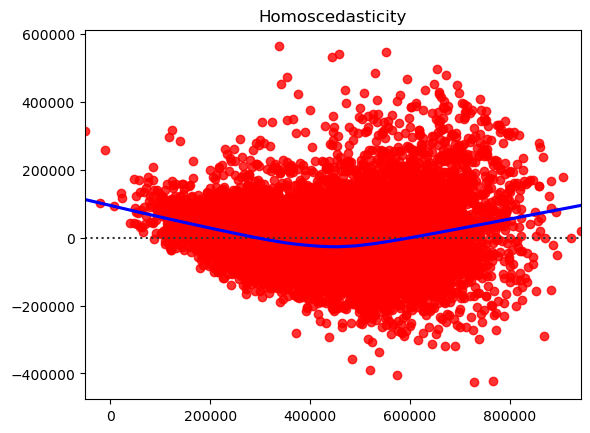

In [216]:
sns.residplot(x=model_ols.fittedvalues, y=model_ols.resid, lowess=True, color='red', line_kws={'color': 'blue'})
plt.title('Homoscedasticity')
plt.show()

In [217]:
statistic, p_value, _, __ = het_breuschpagan(model_ols.resid, model_ols.model.exog)
print(p_value)

4.731753943532817e-216


In [218]:
model_robust = model_ols.get_robustcov_results()
print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.730
Method:                 Least Squares   F-statistic:                     3112.
Date:                Tue, 14 Jan 2025   Prob (F-statistic):               0.00
Time:                        01:03:14   Log-Likelihood:            -1.5570e+05
No. Observations:               12104   AIC:                         3.114e+05
Df Residuals:                   12095   BIC:                         3.115e+05
Df Model:                           8                                         
Covariance Type:                  HC1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.295e+05    849.554    505.583      0.0

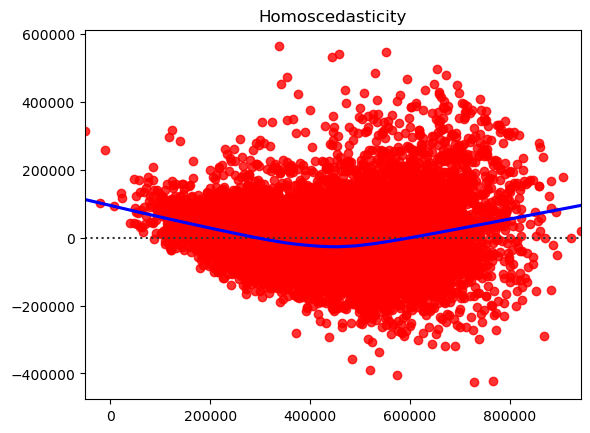

In [219]:
sns.residplot(x=model_robust.fittedvalues, y=model_robust.resid, lowess=True, color='red', line_kws={'color': 'blue'})
plt.title('Homoscedasticity')
plt.show()

In [221]:
model_ols.resid.mean() 

-1.0401974459870005e-09

### Autocorrelation of residuals

In [223]:
durbin_watson(model_ols.resid)

1.9951252076930928